In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [118]:
train = pd.read_csv("titanic_train.csv")
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [119]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

<Axes: >

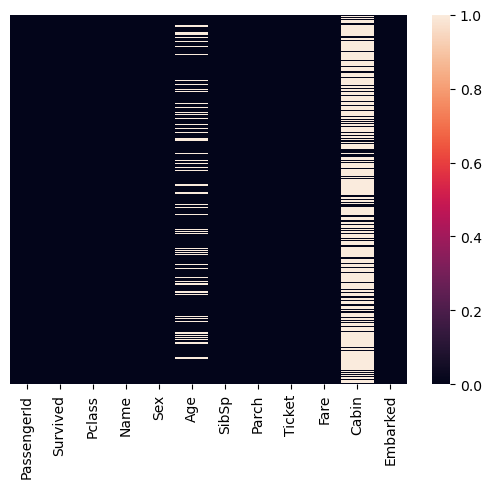

In [120]:
sns.heatmap(train.isnull(), yticklabels=False)

<Axes: xlabel='Survived', ylabel='count'>

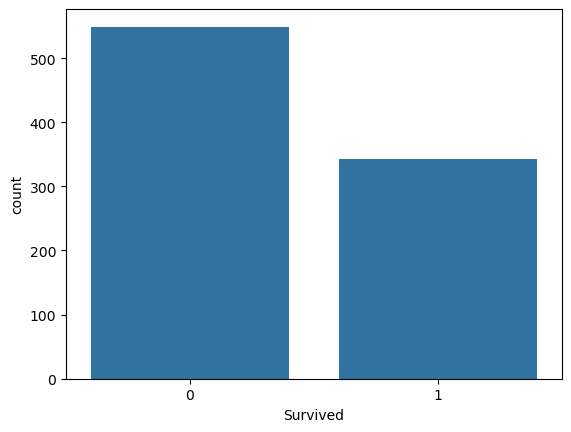

In [121]:
sns.countplot(x='Survived', data=train)

<Axes: xlabel='Survived', ylabel='count'>

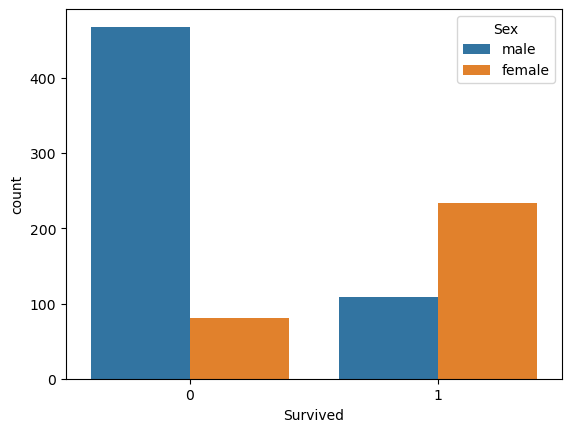

In [122]:
sns.countplot(x='Survived', data=train, hue="Sex")

<Axes: xlabel='Survived', ylabel='count'>

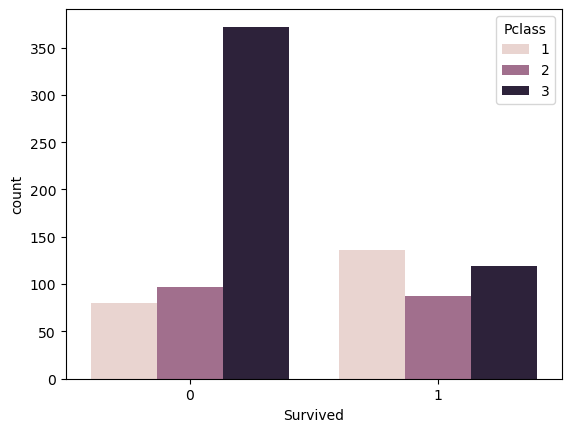

In [123]:
sns.countplot(x='Survived', data=train, hue='Pclass')

In [124]:
cat_cols = train.select_dtypes(include=['object', 'category'])
catColumns = cat_cols.columns.to_list()
catColumns.remove('Ticket')
catColumns.remove('Cabin')
catColumns.remove('Name')

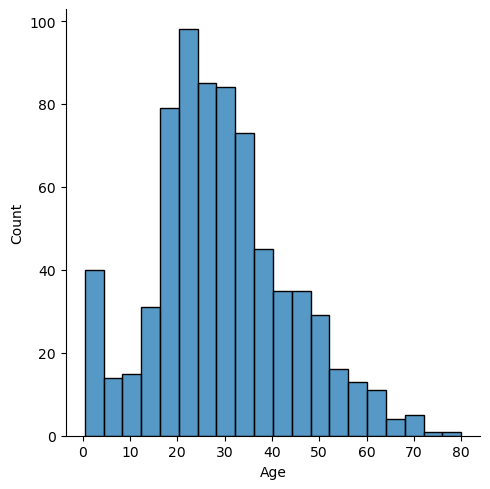

In [125]:
sns.displot(x='Age', data=train)

<Axes: xlabel='SibSp', ylabel='count'>

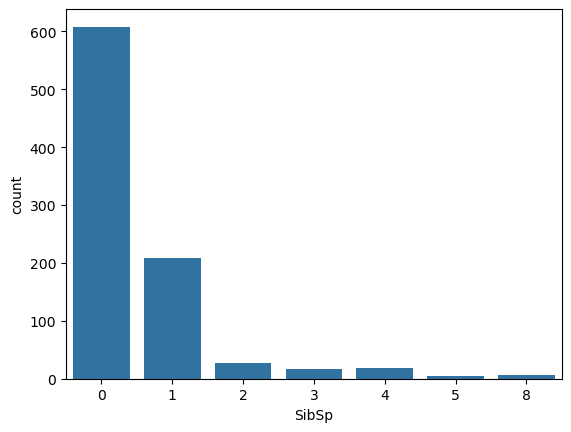

In [126]:
sns.countplot(x='SibSp', data=train)
# train.columns

In [127]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [128]:
import cufflinks as cf

In [129]:
cf.go_offline()

In [130]:
train['Fare'].iplot(kind='hist')

In [131]:
train.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

<Axes: >

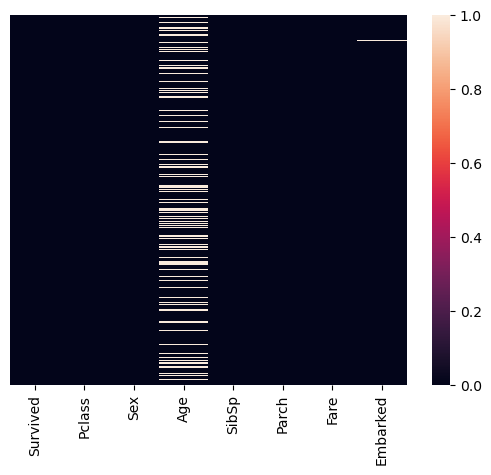

In [132]:
sns.heatmap(train.isnull(), yticklabels=False)

In [133]:
def imputeAge(cols):
    age = cols[0]
    pclass = cols[1]
    if pd.isnull(age):
        if pclass == 1:
            return 35
        elif pclass == 2:
            return 29
        else:
            return 24
    else:
        return age

In [134]:
train['Age'] = train[['Age', 'Pclass']].apply(imputeAge, axis=1)

/var/folders/x1/vmgj69g51xgbn4fgdlm5lb800000gn/T/ipykernel_3424/2771661315.py:2: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/var/folders/x1/vmgj69g51xgbn4fgdlm5lb800000gn/T/ipykernel_3424/2771661315.py:3: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



<Axes: >

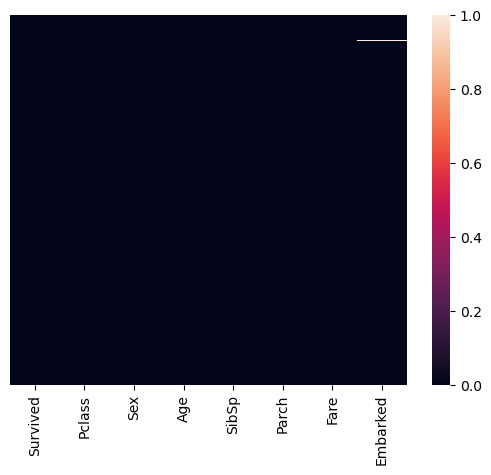

In [135]:
sns.heatmap(train.isnull(), yticklabels=False)

In [136]:
train.dropna(axis=0, inplace=True)

In [137]:
train

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,24.0,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [138]:
sex = pd.get_dummies(train['Sex'], drop_first=True)
embarked = pd.get_dummies(train['Embarked'], drop_first=True)

In [139]:
sex

,male
0,True
1,False
2,False
3,False
4,True
...,...
886,True
887,False
888,False
889,True


In [140]:
train = pd.concat([train, sex, embarked], axis=1)

In [141]:
train.drop(['Sex', 'Embarked'], axis=1, inplace=True)

In [142]:
train

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True
...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,True,False,True
887,1,1,19.0,0,0,30.0000,False,False,True
888,0,3,24.0,1,2,23.4500,False,False,True
889,1,1,26.0,0,0,30.0000,True,False,False


In [145]:
X = train.drop('Survived', axis=1)

In [146]:
X

,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True
...,...,...,...,...,...,...,...,...
886,2,27.0,0,0,13.0000,True,False,True
887,1,19.0,0,0,30.0000,False,False,True
888,3,24.0,1,2,23.4500,False,False,True
889,1,26.0,0,0,30.0000,True,False,False


In [147]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, train['Survived'], test_size=0.30, random_state=101)

In [164]:
from sklearn.linear_model import LogisticRegression
log = LogisticRegression(max_iter=2000, penalty='elasticnet', solver='saga',l1_ratio=0.5)
log.fit(X_train, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



,penalty,'elasticnet'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'saga'
,max_iter,2000
,multi_class,'deprecated'


In [165]:
predictions = log.predict(X_test)

In [166]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, predictions)

array([[156,   7],
       [ 72,  32]])

In [167]:
from sklearn.metrics import classification_report
report = classification_report(y_test, predictions, output_dict=True)
print(report)

{'0': {'precision': 0.6842105263157895, 'recall': 0.9570552147239264, 'f1-score': 0.7979539641943734, 'support': 163.0}, '1': {'precision': 0.8205128205128205, 'recall': 0.3076923076923077, 'f1-score': 0.44755244755244755, 'support': 104.0}, 'accuracy': 0.704119850187266, 'macro avg': {'precision': 0.752361673414305, 'recall': 0.6323737612081171, 'f1-score': 0.6227532058734104, 'support': 267.0}, 'weighted avg': {'precision': 0.7373020566397266, 'recall': 0.704119850187266, 'f1-score': 0.6614679801840353, 'support': 267.0}}
